# Pre-series04-Python

## Import libraries

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

# 1. Generate a known signal 

Equation of a sinusoid at 1Hz, with amplitude 1 and phase 0 :
$$s(t) = A\sin(2\pi f t + \varphi),\quad A=1,\ f=1\,\text{Hz},\ \varphi=0 \;\Rightarrow\; s(t)=\sin(2\pi t)$$

We build a 3D signal $(x, y, z)$ from the same 1 Hz sinusoid, with a constant phase shift $\Delta\varphi = \pi/4$ applied successively from one axis to the next: $y$ is shifted by $\Delta\varphi$ relative to $x$, and $z$ is shifted by $\Delta\varphi$ relative to $y$. Therefore, $z$ is shifted by $2\Delta\varphi = \pi/2$ relative to $x$:

$$x(t)=\sin(2\pi t),\quad y(t)=\sin\!\left(2\pi t+\tfrac{\pi}{4}\right),\quad z(t)=\sin\!\left(2\pi t+\tfrac{\pi}{2}\right)$$

In general, for axis $k \in \{0, 1, 2\}$ (x, y, z): $s_k(t) = \sin(2\pi t + k\,\Delta\varphi)$. This is implemented with `phases = phi0 + phase_shift * np.arange(3)`, and NumPy broadcasting applies one phase per column of `time` (shape `(n, 1)`).

t.shape = (100, 1)
s.shape = (100, 3)
phase_shift = 0.25 pi


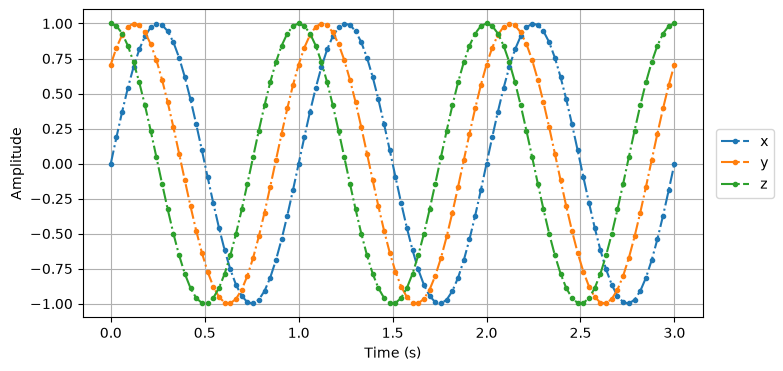

In [8]:
# Parameters 

f = 1.0                 # frequency (Hz)
A = 1.0                 # amplitude
phi0 = 0.0              # initial phase (rad)
n_samples = 100       # number of samples
duration = 3.0          # duration (s)
phase_shift = np.pi / 4 # phase shift between x->y and y->z (rad)

# Time vector

time = np.linspace(0, duration, n_samples).reshape(-1, 1)   # shape (n, 1)

# Signal (x, y, z) in columns

phases = phi0 + phase_shift * np.arange(3)           # [0, pi/4, pi/2]
signal = A * np.sin(2 * np.pi * f * time + phases)   # broadcasting -> (n, 3)

# Check 

print(f"t.shape = {time.shape}")
print(f"s.shape = {signal.shape}")
print(f"phase_shift = {phase_shift/np.pi:g} pi")

# Plot 2D figure 

fig2d, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate("xyz"):
    ax.plot(time, signal[:, i], ".-.", label=name)   # points reliés en pointillés
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.show()

